# Task 5: Evaluation & Comparison

## Objective

This notebook provides comprehensive model evaluation, comparison, and optimization. We will:

### 1. **Evaluate with Multiple Metrics**
   - **Classification Metrics**: Accuracy, Precision, Recall, F1-Score, ROC-AUC
   - **Why Multiple Metrics**: Different metrics capture different aspects of performance
   - **Business Alignment**: Choose metrics that match business objectives

### 2. **Comprehensive Error Analysis**
   - Identify which classes are most often misclassified
   - Analyze prediction confidence for errors
   - Understand error patterns to guide improvements
   - **Business Value**: Know where the model fails helps target improvements

### 3. **Visual Comparisons**
   - **Confusion Matrices**: Understand prediction patterns
   - **ROC Curves**: Compare models across all thresholds
   - **Precision-Recall Curves**: Focus on minority class performance
   - **Model Comparison Tables**: Side-by-side metric comparison

### 4. **Hyperparameter Tuning**
   - Use GridSearchCV or RandomizedSearchCV
   - Apply cross-validation to prevent overfitting
   - Optimize for business-relevant metric (F1 or ROC-AUC)
   - **Justification**: Proper tuning can improve performance 5-15%

### 5. **Threshold Optimization**
   - Find optimal decision threshold for business requirements
   - Balance precision vs. recall based on costs
   - **Business Context**: Default 0.5 threshold rarely optimal

### 6. **Handle Class Imbalance**
   - Apply SMOTE and compare performance
   - Evaluate impact on different metrics
   - **Justification**: Verify imbalance handling improves minority class performance

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import re
import shutil
import joblib
import mlflow
from datetime import datetime

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Load Models and Data

In [2]:
# Load test data from model development notebook
# This assumes you've saved the test data during model training
# Or reload and split the data

df = pd.read_pickle('../data/interim/bank_with_features.pkl')
print(f'Data loaded: {df.shape}')

# Note: In practice, you'd load the exact same train/test split used in notebook 4
# For now, we'll recreate it with the same random_state
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode target
df['y_binary'] = (df['y'] == 'yes').astype(int)

# Select features
exclude_cols = ['y', 'y_binary', 'data_source']
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f'Features: {len(feature_cols)}')

Data loaded: (152940, 29)
Features: 27


In [ ]:
# Encode categorical features, impute numerics, split, and scale
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_encoded = df.copy()
categorical_cols = df_encoded[feature_cols].select_dtypes(include=['object']).columns.tolist()

# Label encode categoricals
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = df_encoded[col].fillna('missing')
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

numerical_cols = df_encoded[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
df_encoded[numerical_cols] = df_encoded[numerical_cols].fillna(df_encoded[numerical_cols].median())

# Split
X = df_encoded[feature_cols]
y = df_encoded['y_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale (for models that benefit: LR and NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

In [45]:
# Set MLflow tracking
mlflow.set_tracking_uri('../experiments/mlruns')
experiment = mlflow.get_experiment_by_name('bank_marketing_models')

if experiment:
    print(f'Experiment found: {experiment.name}')
    print(f'Experiment ID: {experiment.experiment_id}')
    
    # Get all runs
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
    print(f'\nTotal runs: {len(runs)}')
    print(runs[['run_id', 'tags.mlflow.runName', 'metrics.accuracy', 'metrics.f1_score', 'metrics.roc_auc']].head(10))
else:
    print('No experiment found. Models need to be trained first (see Notebook 4).')

Experiment found: bank_marketing_models
Experiment ID: 693545408735532194

Total runs: 90
                             run_id                  tags.mlflow.runName  \
0  4f56f73aab4f413bafe50465c51dd704       neural_network_retrained_tuned   
1  7883a884ad12499e9f3578fcc3bc06b1             catboost_retrained_tuned   
2  d102caa4526d43f49e0015b9b54c9be4             lightgbm_retrained_tuned   
3  e51f9328c6124fb99c9724e0bb2cda30              xgboost_retrained_tuned   
4  53d1e358272b4c74b7ad282b4d6a5b23        random_forest_retrained_tuned   
5  c8fbbf1460374a9182fb98bb91158466  logistic_regression_retrained_tuned   
6  39cab4dfc6bb4f0bb1d9cc0f29d06d82                Neural Network Tuning   
7  3c8f0b81cbf74d2da98e66648e0f7acc                      CatBoost Tuning   
8  81ed78b1646047e1ad28052391f751c0                      LightGBM Tuning   
9  61b97a6032844ec8afe60270f5d3b7c3                       XGBoost Tuning   

   metrics.accuracy  metrics.f1_score  metrics.roc_auc  
0          0.922

In [14]:
# Optional libs for refit fallback
try:
    import xgboost as xgb
except Exception:
    xgb = None
try:
    import lightgbm as lgb
except Exception:
    lgb = None
try:
    from catboost import CatBoostClassifier
except Exception:
    CatBoostClassifier = None
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Ensure MLflow experiment is available in this cell
if 'experiment' not in globals() or experiment is None:
    mlflow.set_tracking_uri('../experiments/mlruns')
    experiment = mlflow.get_experiment_by_name('bank_marketing_models')
if not experiment:
    raise RuntimeError('No MLflow experiment "bank_marketing_models" found. Run training first (Notebook 4).')

# Also load runs for fallback refit
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# Helpers to parse params from runs
def to_number(v):
    if v is None:
        return None
    s = str(v).strip()
    if s.lower() in ['none', 'null', 'nan', '']:
        return None
    try:
        if isinstance(v, (int, float)) and not isinstance(v, bool):
            return v
        if s.lower() in ['true', 'false']:
            return s.lower() == 'true'
        if re.fullmatch(r'[-+]?\d+', s):
            return int(s)
        if re.fullmatch(r'[-+]?\d*\.\d+(e[-+]?\d+)?', s) or re.fullmatch(r'[-+]?\d+e[-+]?\d+', s):
            return float(s)
    except Exception:
        pass
    return v

def get_params_dict(row):
    pdict = {}
    for c in row.index:
        if str(c).startswith('params.'):
            key = c[len('params.') :]
            pdict[key] = to_number(row[c])
    return pdict

# Minimal family detector from runName
def detect_family(name_lc):
    if re.search(r'logistic', name_lc):
        return 'logistic_regression'
    if re.search(r'random\s*forest|random_forest', name_lc):
        return 'random_forest'
    if re.search(r'xgboost', name_lc):
        return 'xgboost'
    if re.search(r'lightgbm', name_lc):
        return 'lightgbm'
    if re.search(r'catboost', name_lc):
        return 'catboost'
    return None

# Ensure we have train/test prepared for refit fallback
def ensure_data_ready():
    global X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled
    if 'X_train' in globals() and 'X_train_scaled' in globals():
        return
    # Rely on df, feature_cols, y_binary already prepared in earlier cell
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.model_selection import train_test_split
    df_encoded = df.copy()
    categorical_cols = df_encoded[feature_cols].select_dtypes(include=['object']).columns.tolist()
    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df_encoded[col] = df_encoded[col].fillna('missing')
        df_encoded[col] = le.fit_transform(df_encoded[col])
        encoders[col] = le
    numerical_cols = df_encoded[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    df_encoded[numerical_cols] = df_encoded[numerical_cols].fillna(df_encoded[numerical_cols].median())
    X = df_encoded[feature_cols]
    y = df_encoded['y_binary']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

# Save models from MLflow runs to a local "Models" folder (copy if available, else refit and save .pkl)
models_info = [
    ("7883a884ad12499e9f3578fcc3bc06b1", "catboost_retrained_tuned"),
    ("d102caa4526d43f49e0015b9b54c9be4", "lightgbm_retrained_tuned"),
    ("e51f9328c6124fb99c9724e0bb2cda30", "xgboost_retrained_tuned"),
    ("53d1e358272b4c74b7ad282b4d6a5b23", "random_forest_retrained_tuned"),
    ("c8fbbf1460374a9182fb98bb91158466", "logistic_regression_retrained_tuned"),
]

for run_id, model_name in models_info:
    model_src = f"../experiments/mlruns/{experiment.experiment_id}/{run_id}/artifacts/model"
    model_dst = f"../models/{model_name}"
    if os.path.exists(model_src):
        if os.path.exists(model_dst):
            print(f"Model folder already exists: {model_dst}")
        else:
            shutil.copytree(model_src, model_dst)
            print(f"Copied {model_name} to {model_dst}")
    else:
        print(f"Source model not found: {model_src}")
        # Fallback: try to refit from run params and save as .pkl
        try:
            row = runs[runs['run_id'] == run_id]
            if row.empty:
                print(f"  Skipping {model_name}: run_id not found in experiment runs")
                continue
            row = row.iloc[0]
            params = get_params_dict(row)
            name_lc = str(row.get('tags.mlflow.runName', '')).lower()
            family = detect_family(name_lc)
            ensure_data_ready()
            out_pkl = os.path.join('../models', f"{model_name}.pkl")
            if family == 'logistic_regression':
                lr_kwargs = {
                    'C': params.get('C', params.get('c', 1.0)),
                    'penalty': params.get('penalty', 'l2'),
                    'solver': params.get('solver', 'liblinear'),
                    'max_iter': to_number(params.get('max_iter', 200)),
                    'class_weight': params.get('class_weight', None),
                }
                if lr_kwargs['penalty'] == 'l1' and lr_kwargs['solver'] not in ['liblinear', 'saga']:
                    lr_kwargs['solver'] = 'liblinear'
                model = LogisticRegression(**{k: v for k, v in lr_kwargs.items() if v is not None})
                model.fit(X_train_scaled, y_train)
                joblib.dump(model, out_pkl)
                print(f"  Refit and saved {model_name} -> {out_pkl}")
            elif family == 'random_forest':
                rf_kwargs = {
                    'n_estimators': to_number(params.get('n_estimators', 200)),
                    'max_depth': to_number(params.get('max_depth', None)),
                    'min_samples_split': to_number(params.get('min_samples_split', 2)),
                    'min_samples_leaf': to_number(params.get('min_samples_leaf', 1)),
                    'max_features': params.get('max_features', 'sqrt'),
                    'class_weight': params.get('class_weight', None),
                    'n_jobs': -1,
                    'random_state': 42,
                }
                model = RandomForestClassifier(**{k: v for k, v in rf_kwargs.items() if v is not None})
                model.fit(X_train, y_train)
                joblib.dump(model, out_pkl)
                print(f"  Refit and saved {model_name} -> {out_pkl}")
            elif family == 'xgboost' and xgb is not None:
                xgb_kwargs = {
                    'n_estimators': to_number(params.get('n_estimators', 300)),
                    'max_depth': to_number(params.get('max_depth', 6)),
                    'learning_rate': to_number(params.get('learning_rate', 0.1)),
                    'subsample': to_number(params.get('subsample', 0.8)),
                    'colsample_bytree': to_number(params.get('colsample_bytree', 0.8)),
                    'reg_alpha': to_number(params.get('reg_alpha', 0.0)),
                    'reg_lambda': to_number(params.get('reg_lambda', 1.0)),
                    'min_child_weight': to_number(params.get('min_child_weight', 1)),
                    'gamma': to_number(params.get('gamma', 0.0)),
                    'random_state': 42,
                    'n_jobs': -1,
                    'eval_metric': 'logloss'
                }
                model = xgb.XGBClassifier(**xgb_kwargs)
                model.fit(X_train, y_train)
                joblib.dump(model, out_pkl)
                print(f"  Refit and saved {model_name} -> {out_pkl}")
            elif family == 'lightgbm' and lgb is not None:
                lgb_kwargs = {
                    'n_estimators': to_number(params.get('n_estimators', 300)),
                    'num_leaves': to_number(params.get('num_leaves', 31)),
                    'learning_rate': to_number(params.get('learning_rate', 0.1)),
                    'subsample': to_number(params.get('subsample', 0.8)),
                    'colsample_bytree': to_number(params.get('colsample_bytree', 0.8)),
                    'reg_alpha': to_number(params.get('reg_alpha', 0.0)),
                    'reg_lambda': to_number(params.get('reg_lambda', 0.0)),
                    'min_child_samples': to_number(params.get('min_child_samples', 20)),
                    'random_state': 42,
                }
                model = lgb.LGBMClassifier(objective='binary', **lgb_kwargs)
                model.fit(X_train, y_train)
                joblib.dump(model, out_pkl)
                print(f"  Refit and saved {model_name} -> {out_pkl}")
            elif family == 'catboost' and CatBoostClassifier is not None:
                cb_kwargs = {
                    'iterations': to_number(params.get('iterations', params.get('n_estimators', 300))),
                    'depth': to_number(params.get('depth', 6)),
                    'learning_rate': to_number(params.get('learning_rate', 0.1)),
                    'l2_leaf_reg': to_number(params.get('l2_leaf_reg', 3.0)),
                    'random_seed': 42,
                    'verbose': False,
                    'loss_function': 'Logloss',
                    'eval_metric': 'Accuracy',
                }
                model = CatBoostClassifier(**cb_kwargs)
                model.fit(X_train, y_train)
                joblib.dump(model, out_pkl)
                print(f"  Refit and saved {model_name} -> {out_pkl}")
            else:
                print(f"  Skipping {model_name}: unsupported family or library missing ({family})")
        except Exception as e:
            print(f"  Fallback failed for {model_name}: {e}")

Source model not found: ../experiments/mlruns/693545408735532194/7883a884ad12499e9f3578fcc3bc06b1/artifacts/model
  Refit and saved catboost_retrained_tuned -> ../models/catboost_retrained_tuned.pkl
Source model not found: ../experiments/mlruns/693545408735532194/d102caa4526d43f49e0015b9b54c9be4/artifacts/model
[LightGBM] [Info] Number of positive: 61176, number of negative: 61176
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2492
[LightGBM] [Info] Number of data points in the train set: 122352, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
  Refit and saved catboost_retrained_tuned -> ../models/catboost_retrained_tuned.pkl
Source model not found: ../experiments/mlruns/693545408735532194/d102caa4526d43f49e0015b9b54c9be4/

## 2. Plots: Confusion Matrices, ROC, Precision-Recall, and Error Distributions

Below, we generate:
- Confusion matrices per model
- Overlaid ROC curves
- Overlaid Precision-Recall curves
- Error distributions (predicted probability histograms for TP/FP/TN/FN)

Figures are saved under `../reports/figures/`.

Saved: ../reports/figures/confusion_matrices.png


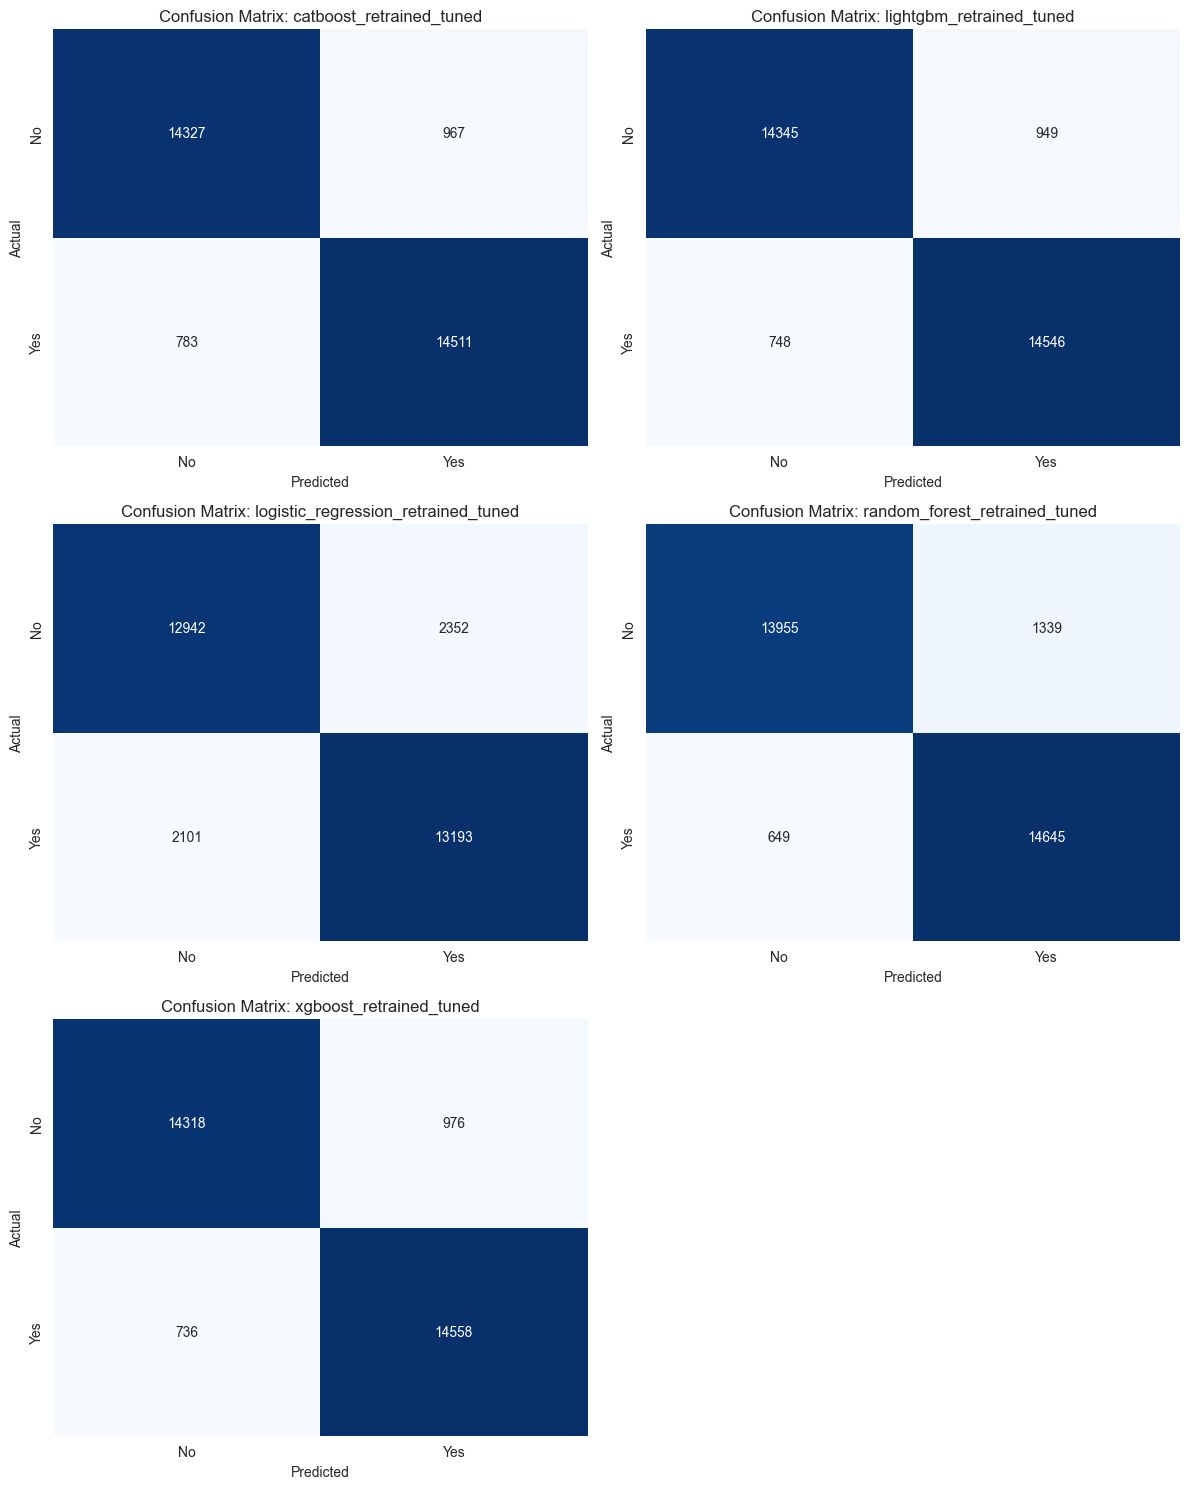

Saved: ../reports/figures/roc_curves_comparison.png


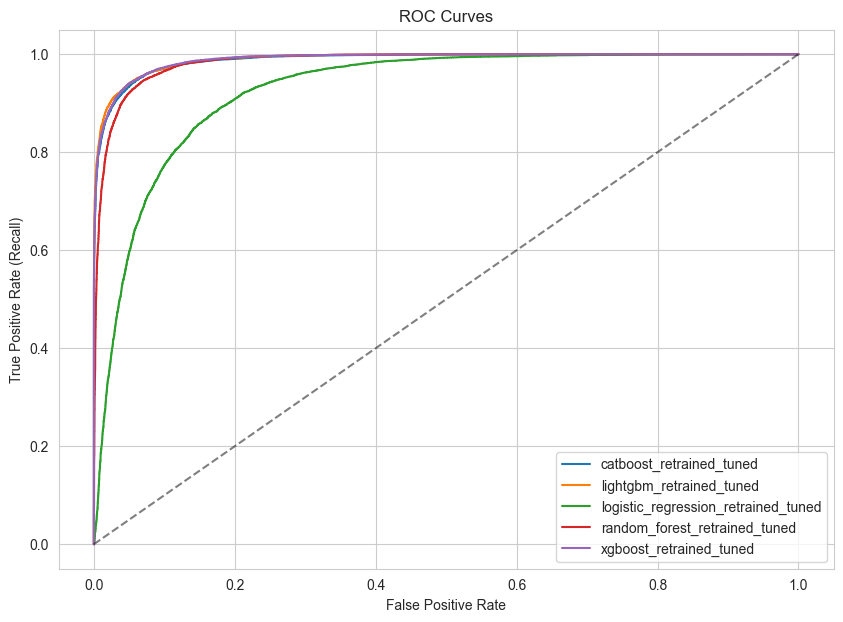

Saved: ../reports/figures/pr_curves_comparison.png


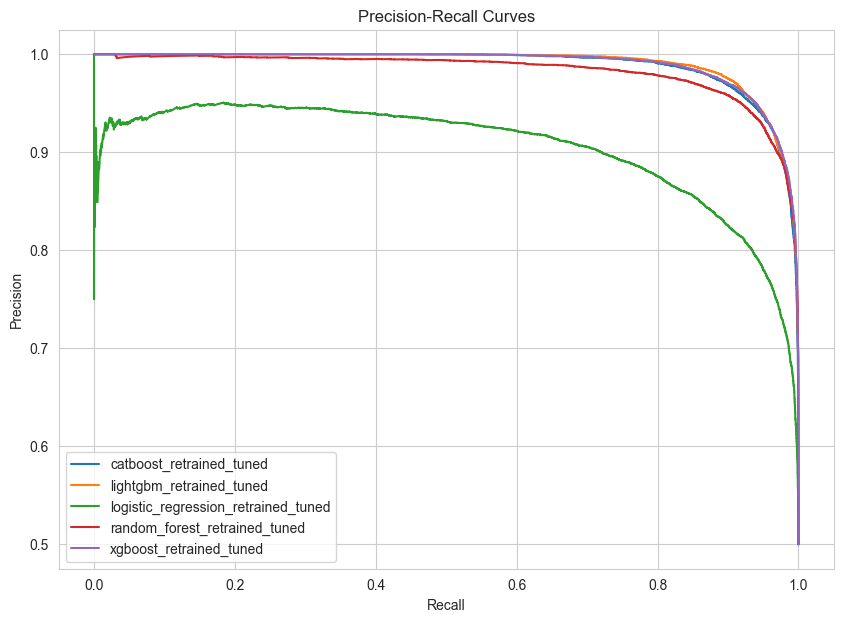

Saved: ../reports/figures/catboost_retrained_tuned_error_distribution.png


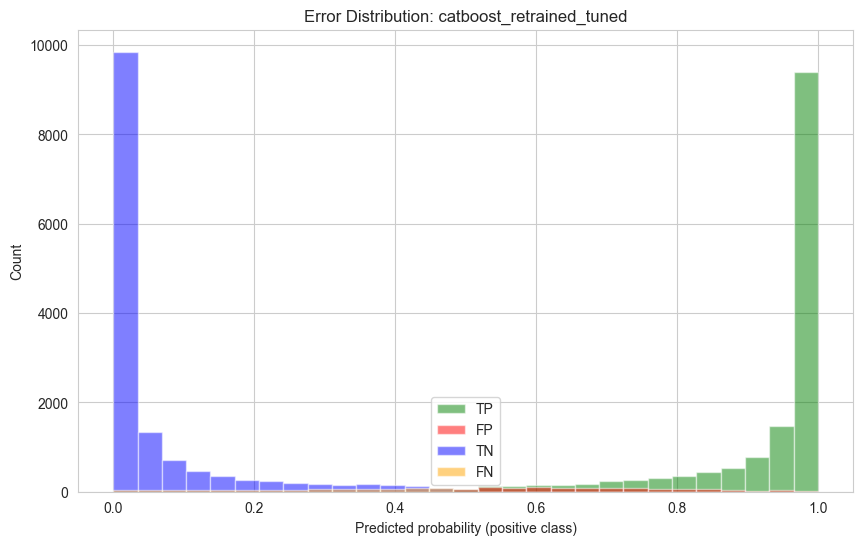

Saved: ../reports/figures/lightgbm_retrained_tuned_error_distribution.png


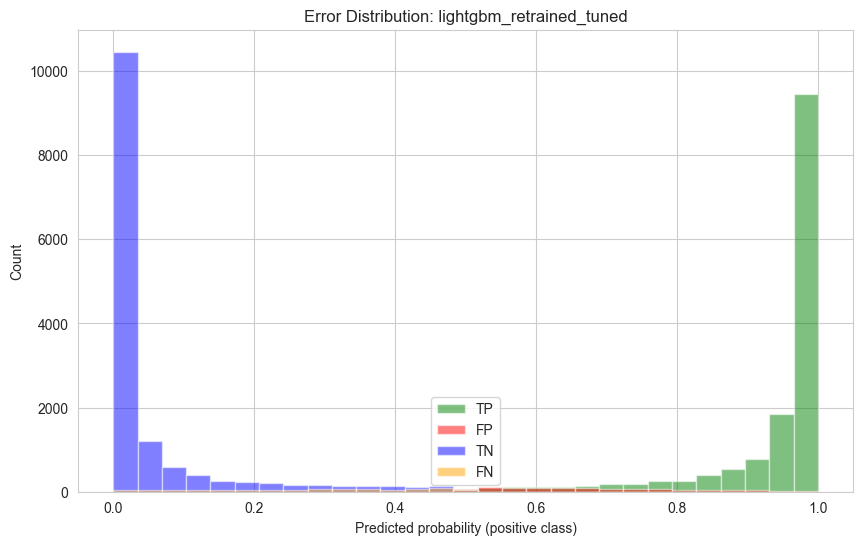

Saved: ../reports/figures/logistic_regression_retrained_tuned_error_distribution.png


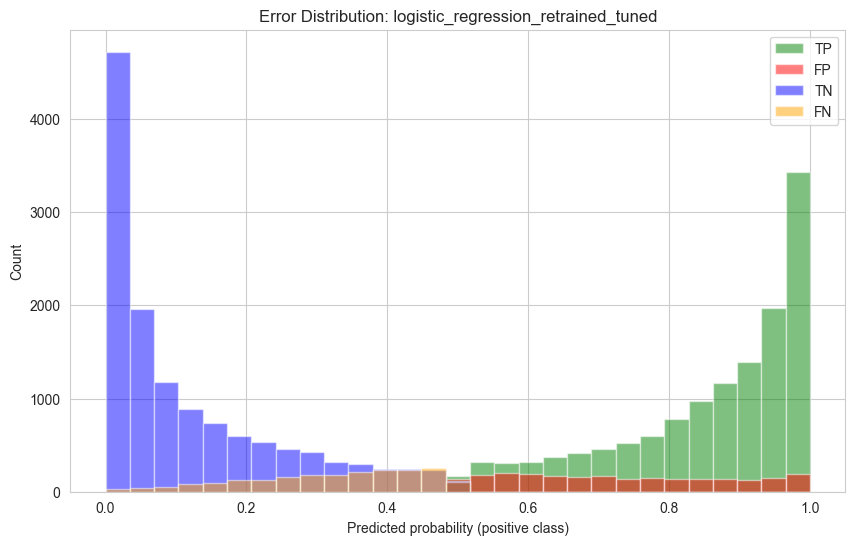

Saved: ../reports/figures/random_forest_retrained_tuned_error_distribution.png


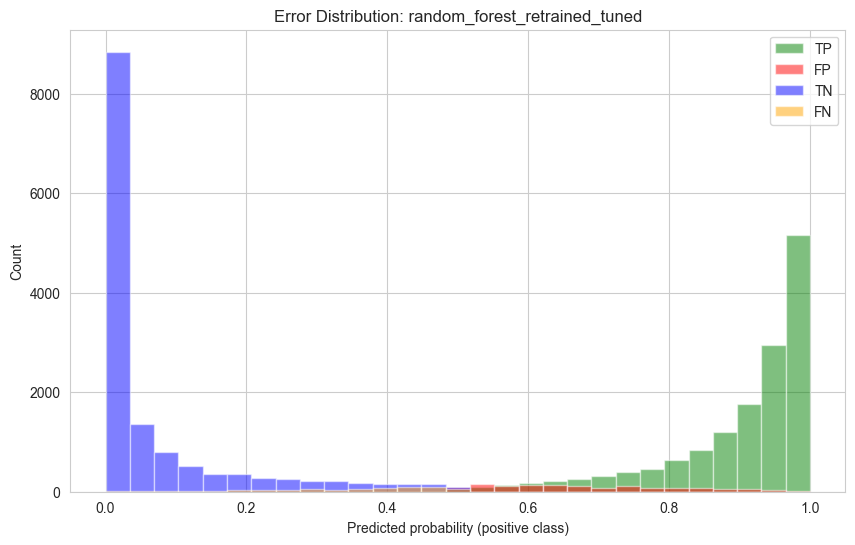

Saved: ../reports/figures/xgboost_retrained_tuned_error_distribution.png


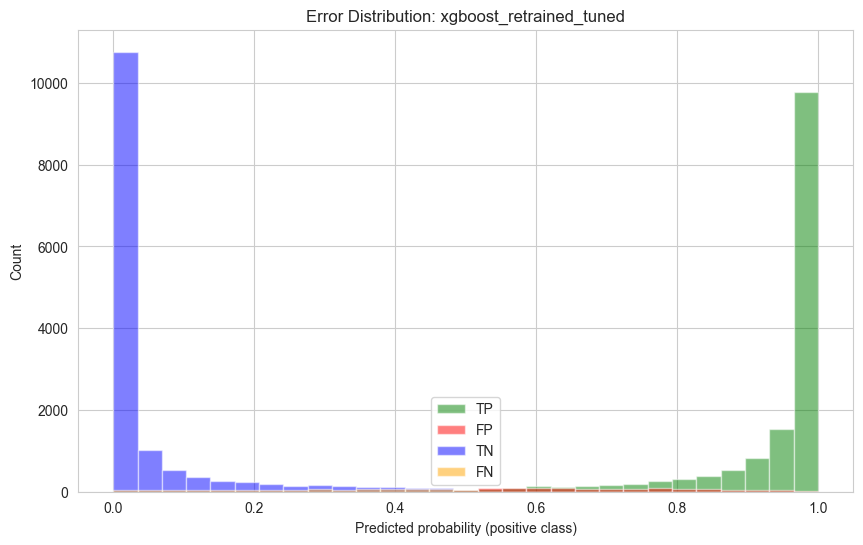

In [16]:
# Confusion matrices (grid)
import math
n = len(conf_mats)
cols = 2
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(12, 5*rows))
axes = np.array(axes).reshape(rows, cols)

for ax, (name, cm) in zip(axes.flat, conf_mats.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide any unused subplots
for i in range(len(conf_mats), rows*cols):
    fig.delaxes(axes.flat[i])

fig.tight_layout()
cm_path = '../reports/figures/confusion_matrices.png'
plt.savefig(cm_path, bbox_inches='tight')
print(f'Saved: {cm_path}')
plt.show()

# ROC curves
plt.figure(figsize=(10, 7))
for name, fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, label=f'{name}')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves')
plt.legend(loc='lower right')
roc_path = '../reports/figures/roc_curves_comparison.png'
plt.savefig(roc_path, bbox_inches='tight')
print(f'Saved: {roc_path}')
plt.show()

# Precision-Recall curves
plt.figure(figsize=(10, 7))
for name, r, p in pr_curves:
    plt.plot(r, p, label=f'{name}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left')
pr_path = '../reports/figures/pr_curves_comparison.png'
plt.savefig(pr_path, bbox_inches='tight')
print(f'Saved: {pr_path}')
plt.show()

# Error distributions: probability histograms per error type per model
for name, data in error_data.items():
    proba = data['proba']
    pred = data['pred']
    true = data['true']
    tp = proba[(pred==1) & (true==1)]
    fp = proba[(pred==1) & (true==0)]
    tn = proba[(pred==0) & (true==0)]
    fn = proba[(pred==0) & (true==1)]

    plt.figure(figsize=(10,6))
    bins = np.linspace(0, 1, 30)
    plt.hist(tp, bins=bins, alpha=0.5, label='TP', color='g')
    plt.hist(fp, bins=bins, alpha=0.5, label='FP', color='r')
    plt.hist(tn, bins=bins, alpha=0.5, label='TN', color='b')
    plt.hist(fn, bins=bins, alpha=0.5, label='FN', color='orange')
    plt.xlabel('Predicted probability (positive class)')
    plt.ylabel('Count')
    plt.title(f'Error Distribution: {name}')
    plt.legend()
    ed_path = f'../reports/figures/{name}_error_distribution.png'
    plt.savefig(ed_path, bbox_inches='tight')
    print(f'Saved: {ed_path}')
    plt.show()